# Loading the model

In [2]:

# Lets import the packages
import torch
from torchvision import transforms
from LymphoMNIST.LymphoMNIST import LymphoMNIST

# check LymphoMNIST virsion
import LymphoMNIST as info
print(f"LymphoMNIST v{info.__version__} @ {info.HOMEPAGE}")

LymphoMNIST v0.0.1 @ https://github.com/Khayrulbuet13/Lympho3-MNIST.git


In [3]:
from data.MyDataset import FilteredLymphoMNIST
from data import get_dataloaders  # Custom function to get dataloaders
from data.transformation import val_transform
from utils import device


# Initialize dataset
original_train_ds = LymphoMNIST(root='./dataset', train=True, download=True, transform=val_transform, num_classes=3)
original_test_ds = LymphoMNIST(root='./dataset', train=False, download=True, transform=val_transform, num_classes=3)


# Specify labels to keep
labels_to_keep = [0, 1] # 0: B, 1: T4, 2: T8

# Initialize filtered dataset with labels to keep
train_ds = FilteredLymphoMNIST(original_train_ds, labels_to_keep)
test_ds= FilteredLymphoMNIST(original_test_ds, labels_to_keep)


train_dl, val_dl, test_dl = get_dataloaders(train_ds,
                                            test_ds,
                                            split=(0.5, 0.5),
                                            batch_size=16,
                                            num_workers=2
                                           )

Dataset already exists. Skipping download.
Dataset already exists. Skipping download.


2024-03-10 20:58:58,050 - [INFO] - Train samples=40800, Validation samples=5100, Test samples=5100


In [4]:
import torch
import torch.nn as nn
from torchvision import models
from torchsummary import summary

# Load a pre-trained ResNet50 model
resnet50 = models.resnet50(weights='IMAGENET1K_V1')


# Adjust the final fully connected layer for your number of classes
num_ftrs = resnet50.fc.in_features
num_classes = 2  # Change to your number of classes
resnet50.fc = nn.Linear(num_ftrs, num_classes)

#load pretrained weights
# resnet50.load_state_dict(torch.load('checkpoint/final_version/BvsT4-idx.pt'))
resnet50.load_state_dict(torch.load('checkpoint/10 March 10:37-modelteacher_final.pt'))



# Move the modified model to CUDA
cnn = resnet50.to(device)

# Assuming your input size is (1, 64, 64), though ResNet typically expects larger images (e.g., 3, 224, 224)
# Adjust the input size if necessary
summary(resnet50, (3, 64, 64))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           9,408
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]           4,096
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,864
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
           Conv2d-11          [-1, 256, 16, 16]          16,384
      BatchNorm2d-12          [-1, 256, 16, 16]             512
           Conv2d-13          [-1, 256, 16, 16]          16,384
      BatchNorm2d-14          [-1, 256,

# Train vs validation accuracy

In [ ]:
import json
import numpy as np

# Replace 'path/to/your/file.json' with the actual path to your JSON file
json_file_path = './paper_viz/teacher/train_acc.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    data = json.load(file)


# Extract 'x' and 'y' values
train_x_values = data[0]['x']
train_y_values = data[0]['y']

# Convert lists to NumPy arrays
train_x_values = np.array(train_x_values)
train_y_values = np.array(train_y_values)




In [ ]:
import json
import numpy as np

# Replace 'path/to/your/file.json' with the actual path to your JSON file
json_file_path = './paper_viz/teacher/val_acc.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    data = json.load(file)


# Extract 'x' and 'y' values
val_x_values = data[0]['x']
val_y_values = data[0]['y']

# Convert lists to NumPy arrays
val_x_values = np.array(val_x_values)
val_y_values = np.array(val_y_values)

In [ ]:
# find a specific value index
index = np.where(train_x_values == 200)
print(index)


In [ ]:

import matplotlib.pyplot as plt

# colors2 = ['#7bbbe0', '#e9a001']
colors2 = ['#1f77b4', '#ff7f0e']

# Plot the data
fig, ax = plt.subplots(figsize=(8,3.5), dpi= 300)
plt.plot(train_x_values[:70], train_y_values[:70], color = colors2[0], lw=2, label='Train Accuracy')
plt.plot(val_x_values[:70], val_y_values[:70], color = colors2[1], lw=2,label='Validation Accuracy')
plt.plot(train_x_values[70], train_y_values[70], 'o', markerfacecolor = colors2[0], markersize=10, markeredgewidth=0.0)
plt.plot(val_x_values[70], val_y_values[70], 'o', markerfacecolor = colors2[1], markersize=10, markeredgewidth=0.0)


font_size=20
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50



# Set tick parameters
ax.tick_params(axis='both', length=10, width=1.5, color= 'gray', direction='in')

# Turn off the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the color of the axes
ax.spines['bottom'].set_color('gray')
ax.spines['left'].set_color('gray')




# plt.title('Training vs Validation Accuracy', fontsize=font_size)
plt.xlabel('Epochs', fontsize=font_size)
plt.ylabel('Accuracy', fontsize=font_size)
plt.legend()

image_name = "paper_viz/teacher/Train_vs_validation_accuracy"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')


# ROC

In [ ]:
cnn.eval()  # set the model to evaluation mode

# Variable for model predictions and true labels
y_pred = []
y_true = []

roc_data = {"train":[], 'val':[]}


with torch.no_grad():
    for image, target in train_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        # Get the probability of the positive class (class 1)
        pos_probs = probs[:, 1]
        y_pred.extend(pos_probs.cpu().numpy())  # Save predicted probabilities
        target = target.data.cpu().numpy()
        y_true.extend(target)  # Save actual labels
        
        



from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
roc_data['train'] = [fpr, tpr, roc_auc]


with torch.no_grad():
    for image, target in val_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        # Get the probability of the positive class (class 1)
        pos_probs = probs[:, 1]
        y_pred.extend(pos_probs.cpu().numpy())  # Save predicted probabilities
        target = target.data.cpu().numpy()
        y_true.extend(target)  # Save actual labels
        
        



from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
roc_data['val'] = [fpr, tpr, roc_auc]


In [ ]:
import matplotlib.pyplot as plt

# Plot ROC curve
plt.figure()
lw = 3  # line width
colors3 = ['#2ba77b', '#e9a001', '#2274b2']

fig, ax = plt.subplots(figsize=(4,4), dpi= 1200)

fpr, tpr, roc_auc = roc_data['train']
plt.plot(fpr, tpr, '-', color=colors3[0], lw=lw, label='Train area = %0.2f' % roc_auc)
fpr, tpr, roc_auc = roc_data['val']
plt.plot(fpr, tpr, '--', color=colors3[1], lw=lw, label='Val area = %0.2f' % roc_auc)

plt.plot([0, 1], [0, 1], color=colors3[2], lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.01])



# plt.legend(loc="lower right")
# plt.show()



font_size=20
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50



# Set tick parameters
ax.tick_params(axis='both', length=5, width=1, color= 'gray', direction='in')

# Turn off the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the color of the axes
ax.spines['bottom'].set_color('gray')
ax.spines['left'].set_color('gray')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic example')
plt.legend(fontsize=font_size*0.7, loc="lower right")


# Modify x and y tick labels
xticks = ax.get_xticks()
yticks = ax.get_yticks()

# Remove the first tick
# if len(xticks) > 1:
#     ax.set_xticks(xticks[1:])
if len(yticks) > 1:
    ax.set_yticks(yticks[1:])

# plt.show()
image_name = "paper_viz/teacher/CNN_ROC"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')


# Confusion matrix

In [5]:
y_pred = []
y_true = []

with torch.no_grad():
    for image, target in test_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        output = (torch.max(outputs, 1)[1]).data.cpu().numpy()
        y_pred.extend(output) # Save Prediction
        target = target.data.cpu().numpy()
        y_true.extend(target) # Save target

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)


font_size=50
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

# Define tick labels
labels = ["B Cell", "T4 Cell"]

fig, ax = plt.subplots(figsize=(10,7), dpi= 300)

original_cmap = plt.cm.get_cmap('rocket')
# create new colormap using the top 40%
new_cmap = plt.cm.colors.ListedColormap(original_cmap(np.linspace(0.7, 1, 256)))


ax = sns.heatmap(cm, annot=True, fmt="d", cmap=new_cmap, xticklabels=labels, yticklabels=labels)
# Set tick parameters
ax.tick_params(axis='both', length=5, width=0.0, color= 'gray', direction='in')


image_name = "paper_viz/teacher/Confusion_test"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')

In [6]:
# Calculate accuracy
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.94


### Train data

In [8]:
y_pred = []
y_true = []

with torch.no_grad():
    for image, target in train_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        output = (torch.max(outputs, 1)[1]).data.cpu().numpy()
        y_pred.extend(output) # Save Prediction
        target = target.data.cpu().numpy()
        y_true.extend(target) # Save target

/tmp/ipykernel_3045242/3991880258.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  original_cmap = plt.cm.get_cmap('rocket')


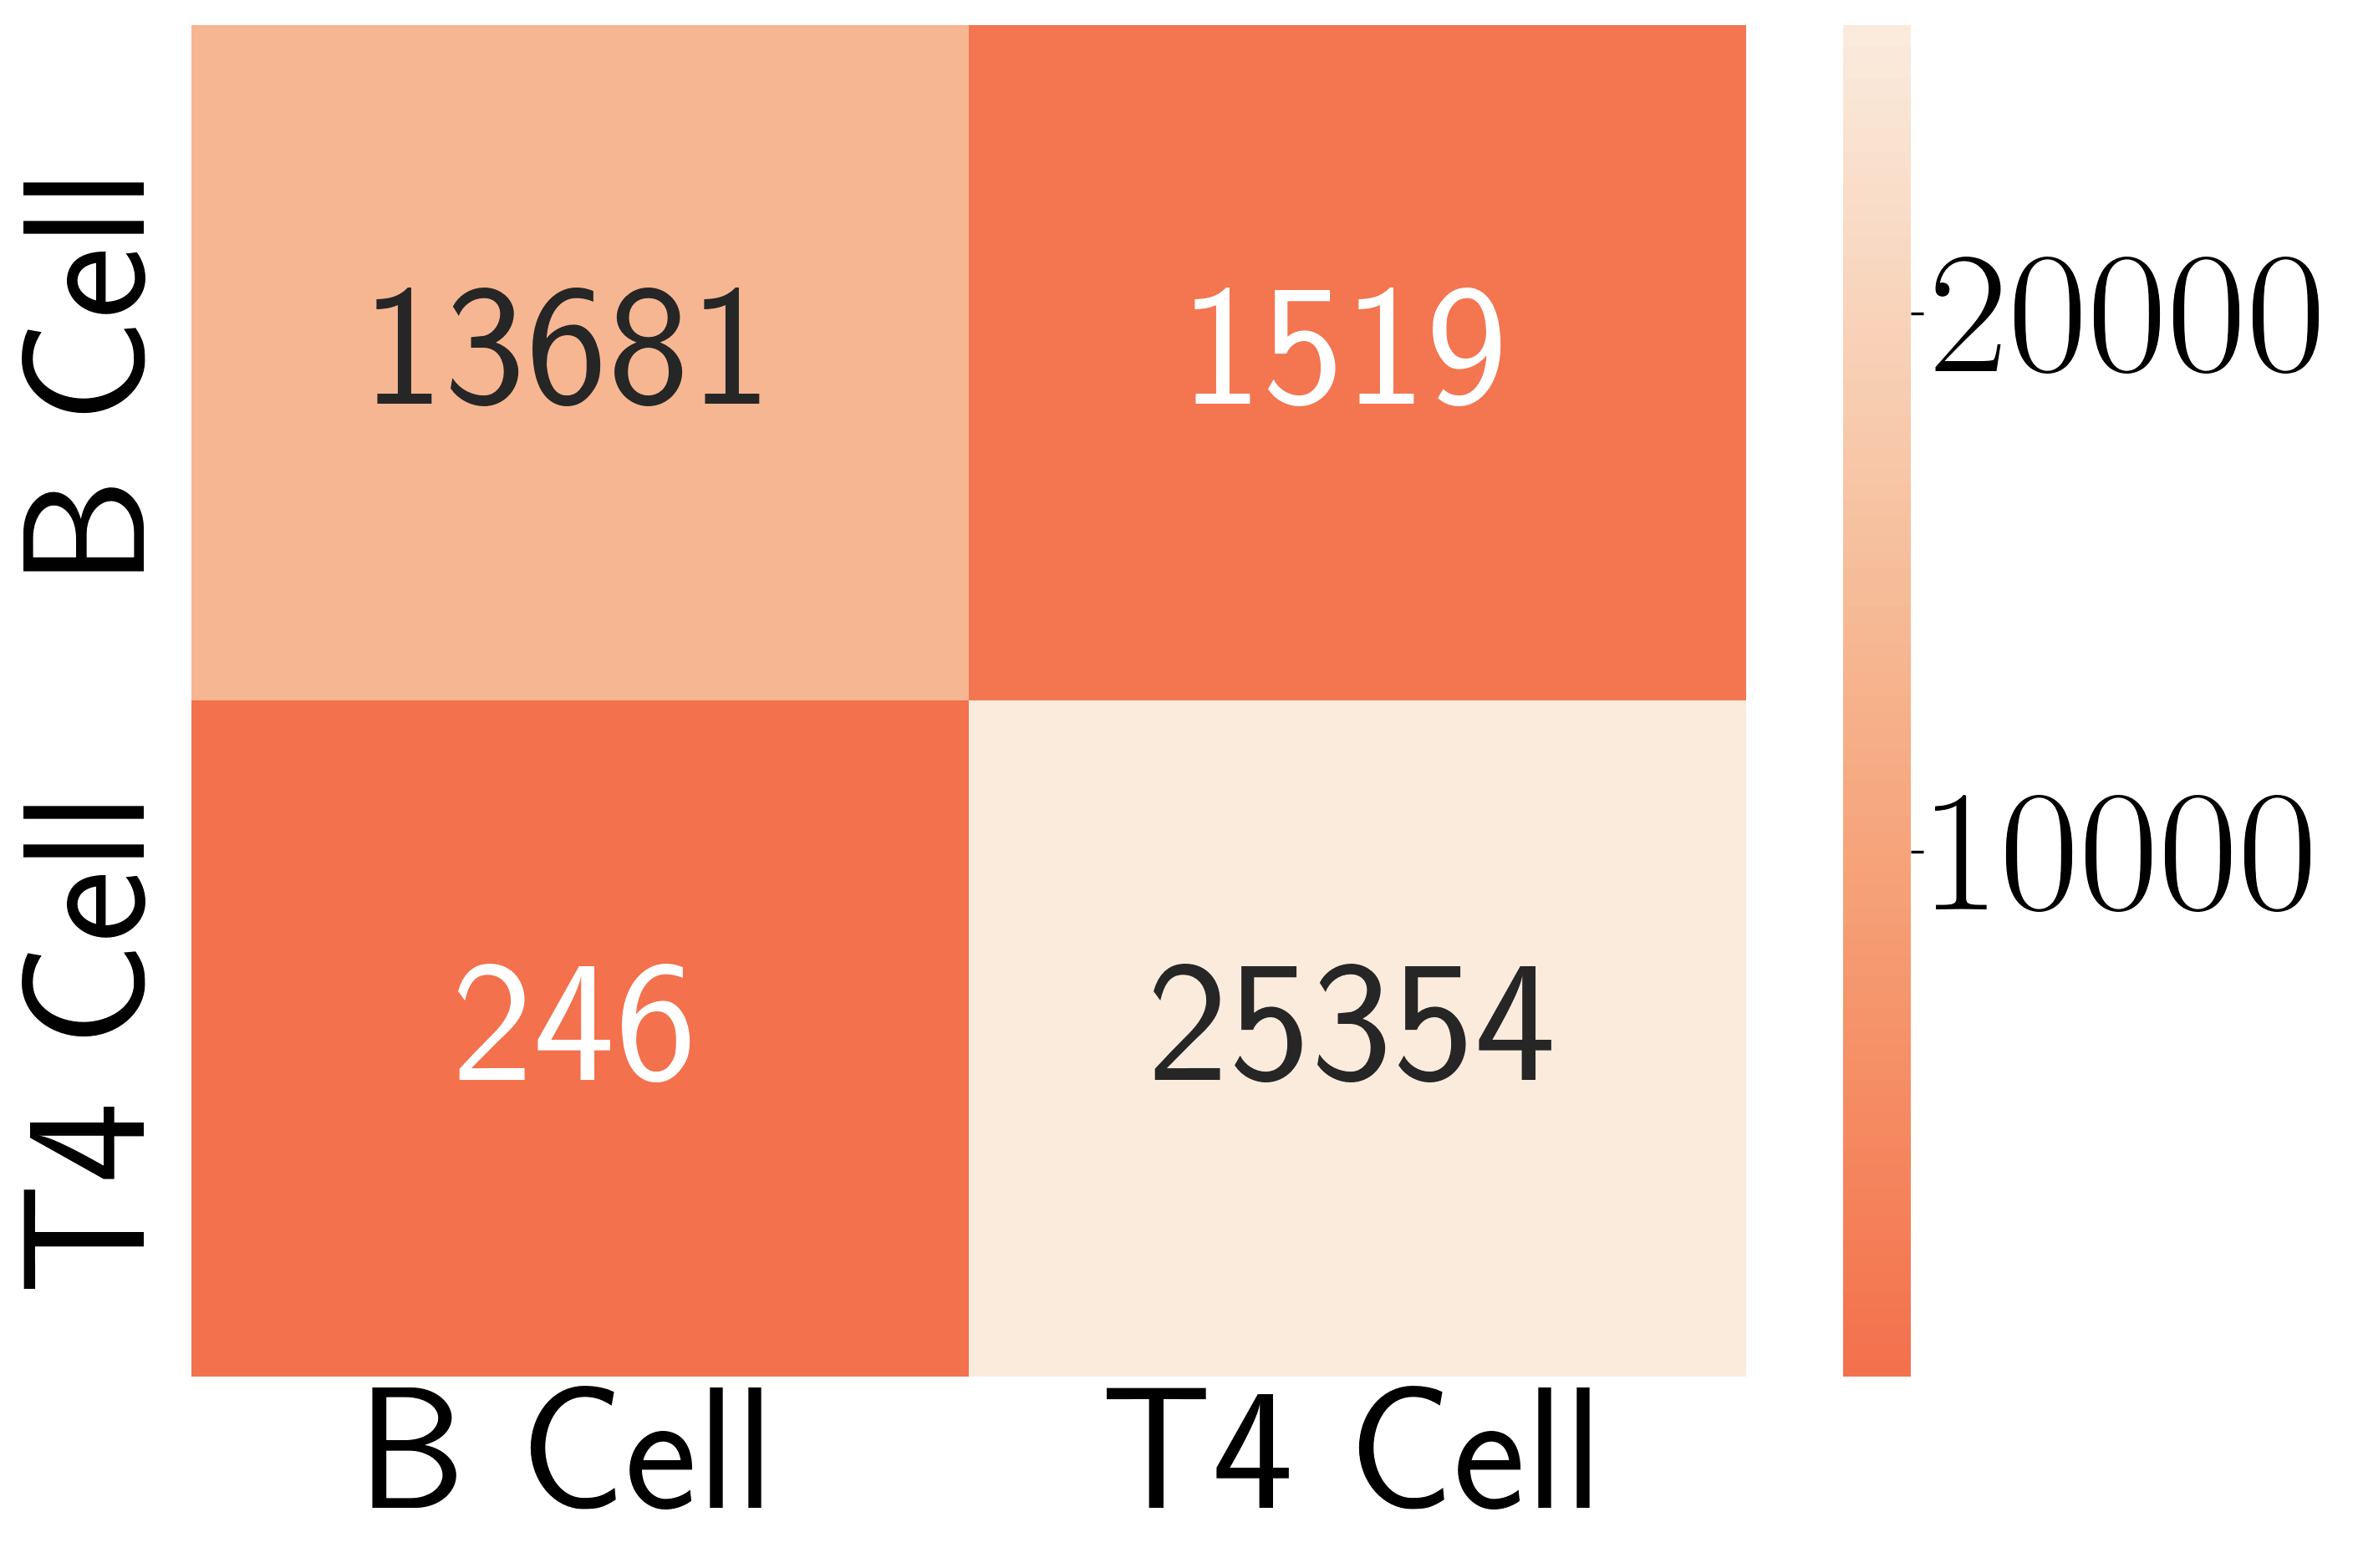

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)


font_size=50
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

# Define tick labels
labels = ["B Cell", "T4 Cell"]

fig, ax = plt.subplots(figsize=(10,7), dpi= 300)

original_cmap = plt.cm.get_cmap('rocket')
# create new colormap using the top 40%
new_cmap = plt.cm.colors.ListedColormap(original_cmap(np.linspace(0.7, 1, 256)))


ax = sns.heatmap(cm, annot=True, fmt="d", cmap=new_cmap, xticklabels=labels, yticklabels=labels)
# Set tick parameters
ax.tick_params(axis='both', length=5, width=0.0, color= 'gray', direction='in')


image_name = "paper_viz/teacher/Confusion_train"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')

In [10]:
# Calculate accuracy
accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.96


# TSNE

In [ ]:
print(cnn)

In [ ]:
# defining hook to access output from intermidiate layer
def get_features(name):
    def hook(model, input, output):
        features[name] = output.detach()
    return hook

# registerning the hook. different layer can be accessed by changing
# fc[3] parameter. for details 
# https://kozodoi.me/python/deep%20learning/pytorch/tutorial/2021/05/27/extracting-features.html

# print(model)
cnn.layer4[2].conv3.register_forward_hook(get_features('feats'))
# cnn.conv1.register_forward_hook(get_features('feats'))


y_pred = []
y_true = []
FEATS = [] # extracted feats will be saved here
# placeholder for batch features
features = {}
# targets = []

with torch.no_grad():
    for image, targets in test_dl:
        image, targets = image.to(device), targets.to(device)
        outputs = cnn(image)
        preds = (torch.max(outputs, 1)[1]).data.cpu().numpy()
        # y_pred.extend(output) # Save Prediction
        # target = target.data.cpu().numpy()
        
        y_true.extend(targets.cpu().numpy())
        y_pred.extend(preds)
        
        
        # targets.extend(target) # Save target
        FEATS.extend((features['feats'].cpu().numpy())) # Save feature
        
y_pred, y_true = np.array(y_pred).reshape(-1,1), np.array(y_true).reshape(-1,1)
FEATS = np.array(FEATS)
print(f' Feature extracted with shape: (m, C, H, W) = {np.array(FEATS).shape}')

In [ ]:
# from sklearn.manifold import TSNE

# # Load the dataset and perform t-SNE embedding
# tsne_proj = TSNE(n_components=2, perplexity= 20,n_iter=400).fit_transform(FEATS.reshape(FEATS.shape[0], -1))

# # save the t-SNE projection
# import pandas as pd
# df = pd.DataFrame(np.concatenate((tsne_proj, y_pred, y_true), axis=1))
# df.to_csv('./paper_viz/teacher/feats.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('./paper_viz/teacher/feats.csv')

# FEATS = last two colimns
tsne_proj = df.iloc[:, -4:-2].values
y_pred, y_true = df.iloc[:, -2].values, df.iloc[:, -1].values
print(f' TSNE shape: (m, n) = {np.array(tsne_proj).shape}')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import numpy as np

colors2 = ['#1f77b4', '#ff7f0e'] # matplotlib default color cycle
font_size=50
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50


fig, ax = plt.subplots(figsize=(20,15), dpi= 300)

# Rename the ticks
plot_labels = ['B Cell', 'T4 Cell']  

for lab in range(2):
    indices = np.array(y_pred)==lab
    indices_flat = indices.flatten()

    sc = ax.scatter(tsne_proj[indices_flat,0],tsne_proj[indices_flat,1], s=150, color=colors2[lab],  label = plot_labels[lab], alpha=0.7)


# plt.legend(fontsize=35)
plt.axis('off')

image_name = "paper_viz/teacher/TSNE_visu"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')

In [ ]:
import numpy as np

# Initialize variables
N, D = 3, 2  # Batch size and dimensionality
embeddings_alpha = np.random.randn(N, D)  # Random embeddings for alpha
embeddings_beta = np.random.randn(N, D)   # Random embeddings for beta

# Define a function to compute cosine similarity
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Compute the loss
loss = 0
for i in range(N):
    cos_ai_bi = cosine_similarity(embeddings_alpha[i], embeddings_beta[i])
    
    sum_cos_ai_bj = 0
    for j in range(N):
        if i != j:
            sum_cos_ai_bj += cosine_similarity(embeddings_alpha[i], embeddings_beta[j])
    
    loss += -cos_ai_bi / sum_cos_ai_bj  # Sum the negative ratios

print(f"Loss: {loss}")


In [ ]:
import numpy as np

# Function to compute cosine similarity
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Loss calculation function
def calculate_loss(alpha_embeddings, beta_embeddings):
    N = alpha_embeddings.shape[0]
    loss = 0
    for i in range(N):
        cos_ai_bi = cosine_similarity(alpha_embeddings[i], beta_embeddings[i])
        
        sum_cos_ai_bj = 0
        for j in range(N):
            if i != j:
                sum_cos_ai_bj += cosine_similarity(alpha_embeddings[i], beta_embeddings[j])
        
        loss += -cos_ai_bi / sum_cos_ai_bj
    return loss

# Initialize base embeddings
N, D = 3, 2  # Batch size and dimensionality
base_embeddings = np.random.randn(N, D)

# Define alpha and beta coefficients
alpha_coefficients = np.array([1, 2])  # Example transformation coefficients for alpha
beta_coefficients = np.array([1, 0.5])  # Example transformation coefficients for beta

# Calculate and print the loss
loss = calculate_loss(alpha_coefficients, beta_coefficients)
print(f"Loss: {loss}")

# Calculate and print the loss
loss = calculate_loss(beta_coefficients, alpha_coefficients)
print(f"Loss: {loss}")
